# 📦 ParcelCast — Notebook 1
## Data Loading, Quality & Exploration

**Purpose:** Take raw M5 data → reframe as parcel forecasting problem → assess
quality → clean systematically → understand the time series.

This notebook proves: *I don't blindly trust data. I assess, document, and
validate before modeling.*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.data_loader import (
    load_and_prepare,
    aggregate_to_weekly,
    CATEGORY_TO_CHANNEL,
    STATE_TO_REGION,
)
from src.parcel_transform import (
    convert_units_to_packages,
    split_packages_by_carrier,
    audit_carrier_shares,
    UPP_BASELINE,
    CARRIER_BASE_SHARES,
)
from src.quality import (
    profile_dataframe,
    detect_outliers_iqr,
    CleaningAuditLog,
    winsorize_with_log,
    interpolate_missing,
    normalize_shares,
    run_validation_suite,
)

sns.set_theme(style="whitegrid", palette="muted")
PRESENTATION_DIR = Path.cwd().parent / "presentation"
PRESENTATION_DIR.mkdir(exist_ok=True)

audit = CleaningAuditLog()

## 1. Load M5 → ParcelCast hierarchy

Mapping applied:
- Store → FC
- State → Region (CA→WEST, TX→SOUTH, WI→MIDWEST)
- Category → Channel (FOODS/HOUSEHOLD → 1P, HOBBIES → MP)

In [2]:
print("Domain mapping:")
print(f"  States → Regions:       {STATE_TO_REGION}")
print(f"  Categories → Channels:  {CATEGORY_TO_CHANNEL}")
print(f"  UPP baselines:          {UPP_BASELINE}")
print(f"  Carrier base shares:    {CARRIER_BASE_SHARES}")

Domain mapping:
  States → Regions:       {'CA': 'WEST', 'TX': 'SOUTH', 'WI': 'MIDWEST'}
  Categories → Channels:  {'FOODS': '1P', 'HOUSEHOLD': '1P', 'HOBBIES': 'MP'}
  UPP baselines:          {'1P': 2.1, 'MP': 1.33}
  Carrier base shares:    {'FedEx': 0.55, 'UPS': 0.15, 'IP': 0.2, 'OnTrac': 0.1}


In [3]:
long_df = load_and_prepare()
print(f"\nLoaded long-format data: {len(long_df):,} rows")
long_df.head()


Loaded long-format data: 59,181,090 rows


,id,item_id,dept_id,cat_id,store_id,state_id,d,units,date,wm_yr_wk,weekday,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,fc_id,region,channel
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,NaN,NaN,0,0,0,CA_1,WEST,MP
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,NaN,NaN,0,0,0,CA_1,WEST,MP
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,NaN,NaN,0,0,0,CA_1,WEST,MP
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,NaN,NaN,0,0,0,CA_1,WEST,MP
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,NaN,NaN,0,0,0,CA_1,WEST,MP


## 2. Aggregate to weekly (region × channel × week)
Retailer fiscal weeks (Saturday-to-Friday).

In [4]:
weekly = aggregate_to_weekly(long_df, by=["region", "channel"])
print(f"Weekly aggregated: {len(weekly):,} rows")
weekly.head()

Weekly aggregated: 1,662 rows


,region,channel,wm_yr_wk,week_start,units
0,WEST,1P,11101,2011-01-29,72459
1,WEST,1P,11102,2011-02-05,76606
2,WEST,1P,11103,2011-02-12,66480
3,WEST,1P,11104,2011-02-19,64972
4,WEST,1P,11105,2011-02-26,67064


## 3. Convert units → packages via UPP

In [5]:
weekly = convert_units_to_packages(weekly)
weekly.head()

,region,channel,wm_yr_wk,week_start,units,upp,packages
0,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714
1,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456
2,WEST,1P,11103,2011-02-12,66480,2.097550,31694.124114
3,WEST,1P,11104,2011-02-19,64972,2.096326,30993.277037
4,WEST,1P,11105,2011-02-26,67064,2.095102,32009.893921


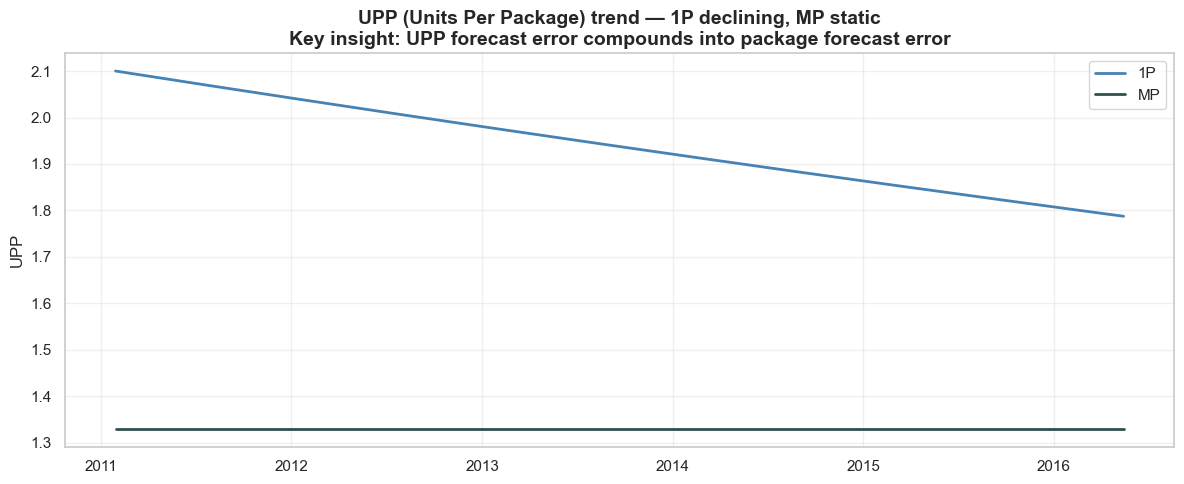

In [6]:
# Show the UPP trend (1P declining, MP static) — the project's key insight
CHANNEL_COLORS = {"1P": "steelblue", "MP": "darkslategray"}
fig, ax = plt.subplots(figsize=(12, 5))
for ch in weekly["channel"].unique():
    sub = weekly[weekly["channel"] == ch].drop_duplicates("week_start")
    ax.plot(sub["week_start"], sub["upp"], label=ch, linewidth=2,
            color=CHANNEL_COLORS.get(ch, "steelblue"))
ax.set_title(
    "UPP (Units Per Package) trend — 1P declining, MP static\n"
    "Key insight: UPP forecast error compounds into package forecast error",
    fontsize=14, fontweight="bold",
)
ax.set_ylabel("UPP")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "01_upp_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Split packages → per-carrier volumes (with regional adjustment)

In [7]:
carrier_df = split_packages_by_carrier(weekly)
print(f"Carrier-level rows: {len(carrier_df):,}")
carrier_df.head(10)

Carrier-level rows: 6,648


,region,channel,wm_yr_wk,week_start,units,upp,packages,carrier,carrier_share,carrier_packages,carrier_cost
0,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714,FedEx,0.487685,16827.213230,143031.312456
1,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714,UPS,0.147783,5099.155524,46912.230823
2,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714,IP,0.216749,7478.761436,47864.073188
3,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714,OnTrac,0.147783,5099.155524,36204.004222
4,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456,FedEx,0.487685,17800.662548,151305.631655
5,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456,UPS,0.147783,5394.140166,49626.089527
6,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456,IP,0.216749,7911.405577,50632.995691
7,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456,OnTrac,0.147783,5394.140166,38298.395178
8,WEST,1P,11103,2011-02-12,66480,2.097550,31694.124114,FedEx,0.487685,15456.740332,131382.292818
9,WEST,1P,11103,2011-02-12,66480,2.097550,31694.124114,UPS,0.147783,4683.860707,43091.518500


In [8]:
# Audit: do carrier shares sum to 1.0?
share_audit = audit_carrier_shares(carrier_df)
print(f"Rows where shares fail sum-to-1: {len(share_audit)}")

Rows where shares fail sum-to-1: 0


## 5. Data Quality Profile

In [9]:
profile = profile_dataframe(carrier_df)
profile

,column,dtype,missing,missing_pct,unique,n,min,max,mean,std,zero_count,zero_pct,negative_count
0,region,str,0,0.0,3,6648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,channel,str,0,0.0,2,6648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,wm_yr_wk,int64,0,0.0,277,6648,11101.000000,11616.000000,11342.88,152.70,0.0,0.0,0.0
3,week_start,datetime64[us],0,0.0,277,6648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,units,int64,0,0.0,1604,6648,3498.000000,121410.000000,40205.37,35444.76,0.0,0.0,0.0
5,upp,float64,0,0.0,278,6648,1.330000,2.100000,1.63,0.31,0.0,0.0,0.0
6,packages,float64,0,0.0,1611,6648,2630.075188,66791.602716,21756.90,17884.36,0.0,0.0,0.0
7,carrier,str,0,0.0,4,6648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,carrier_share,float64,0,0.0,12,6648,0.031088,0.598446,0.25,0.19,0.0,0.0,0.0
9,carrier_packages,float64,0,0.0,6552,6648,81.763995,32573.244674,5439.23,6671.87,0.0,0.0,0.0


In [10]:
# Outlier detection on package volume
outliers = detect_outliers_iqr(carrier_df["carrier_packages"])
print("Carrier-package outlier analysis:")
for k, v in outliers.items():
    print(f"  {k}: {v}")

Carrier-package outlier analysis:
  q1: 934.2054656694415
  q3: 7056.614186409069
  iqr: 6122.408720739627
  lower_bound: -8249.407615439999
  upper_bound: 16240.227267518509
  outliers_low: 0
  outliers_high: 695
  outlier_pct: 10.45


## 6. Cleaning Decisions — with reasoning

**Decision 1: Winsorize extreme volume outliers** — cap at 1st/99th percentile.
Rationale: extreme spikes are likely real (events) but pull model fitting toward
the tail. Winsorization preserves time-series continuity (no row deletion).

In [11]:
carrier_df = winsorize_with_log(
    carrier_df, "carrier_packages", audit,
    lower_pct=0.01, upper_pct=0.99,
    reason="Cap extreme outliers; preserves time-series continuity",
)

**Decision 2: Interpolate missing values** within each (region, channel, carrier)
group. Rationale: linear interpolation preserves temporal patterns; mean fill
would destroy them.

In [12]:
# (M5 has no missing values, but the pipeline supports it)
carrier_df = interpolate_missing(
    carrier_df, "carrier_packages", audit,
    group_cols=["region", "channel", "carrier"],
)

**Decision 3: Renormalize carrier shares** to sum to exactly 1.0 per group.
Rationale: floating-point arithmetic and regional adjustments may introduce
tiny drift; this guarantees consistency.

In [13]:
carrier_df = normalize_shares(
    carrier_df, "carrier_share",
    group_cols=["region", "channel", "week_start"],
    audit=audit,
)

**Decision 4: Recalculate `carrier_packages` = packages × carrier_share.**
Rationale: ensure the derived column is consistent with the (now normalized)
components.

In [14]:
carrier_df["carrier_packages"] = carrier_df["packages"] * carrier_df["carrier_share"]
carrier_df["carrier_cost"] = carrier_df["carrier_packages"] * carrier_df.apply(
    lambda r: {"FedEx": 8.5, "UPS": 9.2, "IP": 6.4, "OnTrac": 7.1}[r["carrier"]],
    axis=1,
)

### Cleaning audit log (the artifact)

In [15]:
audit_df = audit.to_df()
audit_df

,timestamp,action,column,reason,before,after
0,2026-05-11T05:19:29,winsorize,carrier_packages,Cap extreme outliers; preserves time-series co...,"{'min': 81.76399548093029, 'max': 32573.244674...","{'min': 114.70558477256581, 'max': 27341.02039..."
1,2026-05-11T05:19:29,interpolate,carrier_packages,Linear interpolation preserves temporal patter...,{'missing': 0},{'missing': 0}
2,2026-05-11T05:19:29,normalize_shares,carrier_share,Ensure carrier shares sum to exactly 1.0 per g...,{'groups_failing_check': 0},{'groups_failing_check': 0}


## 7. Time-series understanding

**Decomposition** — additive trend + yearly seasonality + residual

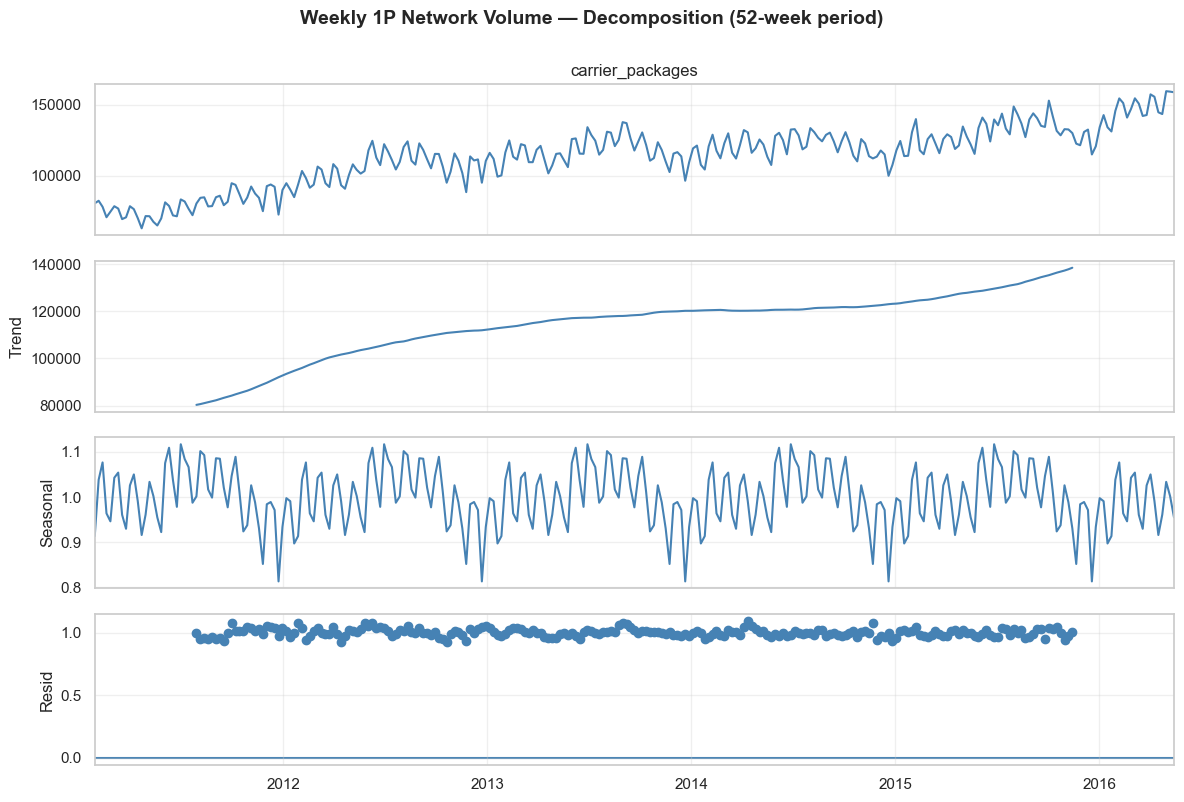

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Pick one series for decomposition: total network 1P weekly volume
network_1p = (
    carrier_df[carrier_df["channel"] == "1P"]
    .groupby("week_start")["carrier_packages"]
    .sum()
    .sort_index()
)

decomp = seasonal_decompose(network_1p, period=52, model="multiplicative")
fig = decomp.plot()
fig.set_size_inches(12, 8)
# Recolor decomposition lines to match the project's primary palette
for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color("steelblue")
    ax.grid(True, alpha=0.3)
fig.suptitle(
    "Weekly 1P Network Volume — Decomposition (52-week period)",
    y=1.0, fontsize=14, fontweight="bold",
)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "02_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

**Stationarity check** — Augmented Dickey-Fuller test

In [17]:
from statsmodels.tsa.stattools import adfuller

adf_stat, p_value, *_ = adfuller(network_1p.dropna())
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value:       {p_value:.4f}")
print(f"=> {'Stationary' if p_value < 0.05 else 'NON-stationary — differencing needed for ARIMA-style models'}")

ADF statistic: -1.1261
p-value:       0.7046
=> NON-stationary — differencing needed for ARIMA-style models


**Correlation analysis** — what drives package volume?

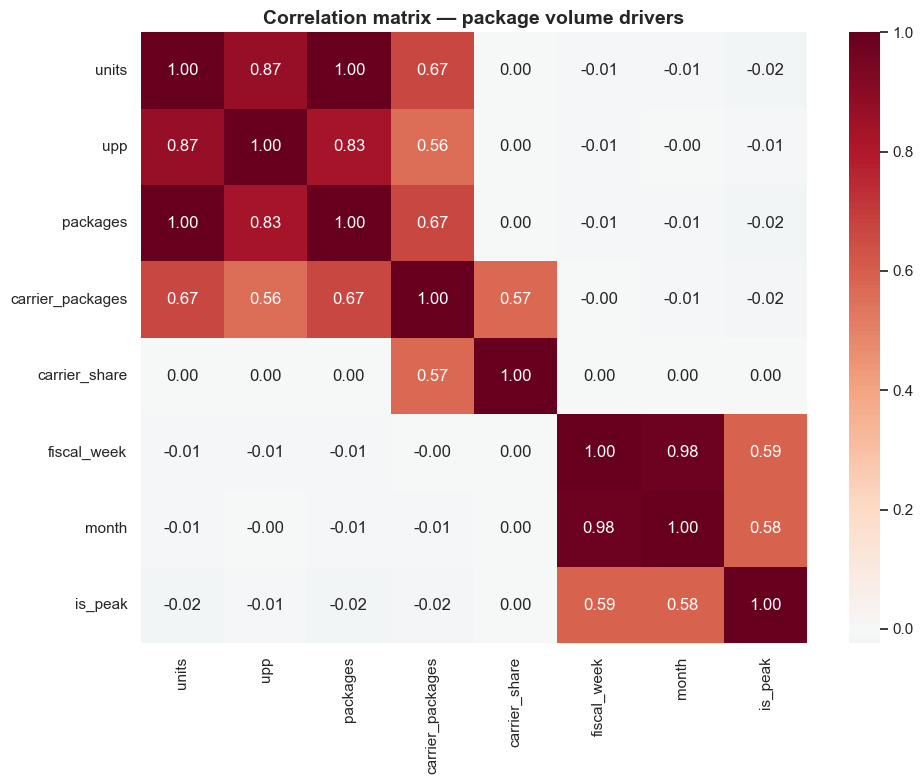

In [18]:
# Build a simple feature set for correlation
corr_df = carrier_df.copy()
corr_df["fiscal_week"] = pd.to_datetime(corr_df["week_start"]).dt.isocalendar().week.astype(int)
corr_df["month"] = pd.to_datetime(corr_df["week_start"]).dt.month
corr_df["is_peak"] = corr_df["fiscal_week"].between(46, 52).astype(int)

corr_features = ["units", "upp", "packages", "carrier_packages", "carrier_share",
                 "fiscal_week", "month", "is_peak"]
corr_matrix = corr_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation matrix — package volume drivers",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Post-cleaning validation suite

In [19]:
validation = run_validation_suite(carrier_df)
validation

,check,pass,detail
0,packages: no missing,True,0 missing
1,packages: no negatives,True,0 negative
2,carrier shares sum to 1.0,True,0 groups fail
3,carrier_packages reconcile to total,True,
4,weeks: no gaps,True,
5,upp: in plausible range,True,0 out of range
6,hierarchy coverage,True,"regions=3, channels=2"
7,"no duplicate (region, channel, carrier, week)",True,0 dups


In [20]:
n_pass = validation["pass"].sum()
n_total = len(validation)
print(f"Validation: {n_pass}/{n_total} checks passed")

Validation: 8/8 checks passed


## 9. Save artifacts

In [21]:
DATA_DIR = Path.cwd().parent / "data"

# Network-level weekly volumes (one row per region × channel × carrier × week)
carrier_df.to_parquet(DATA_DIR / "weekly_network_volumes.parquet", index=False)

# Region+channel weekly (no carrier split — used by modeling notebook)
weekly.to_parquet(DATA_DIR / "weekly_region_channel.parquet", index=False)

# Audit + validation
audit_df.to_csv(DATA_DIR / "cleaning_audit_log.csv", index=False)
validation.to_csv(DATA_DIR / "validation_results.csv", index=False)

print(f"Saved {len(carrier_df):,} rows to weekly_network_volumes.parquet")
print(f"Saved {len(weekly):,} rows to weekly_region_channel.parquet")
print(f"Audit: {len(audit_df)} entries")
print(f"Validation: {n_pass}/{n_total} passed")

Saved 6,648 rows to weekly_network_volumes.parquet
Saved 1,662 rows to weekly_region_channel.parquet
Audit: 3 entries
Validation: 8/8 passed
